# 1D Overdamped Oscillator with Physics-Informed Neural Networks

This notebook demonstrates how to solve the **damped harmonic oscillator** equation using Physics-Informed Neural Networks (PINNs). The damped harmonic oscillator is governed by the second-order differential equation:

$$\frac{d^2x}{dt^2} + \beta \frac{dx}{dt} + \omega x = 0$$

where:
- $\omega$ is the angular frequency squared
- $\beta$ is the damping coefficient
- $x(t)$ is the displacement

Three approaches are demonstrated:
1. **Standard PINN** — single network trained on the full domain
2. **FB-PINN** — domain decomposition with overlapping sub-networks (`PartitionFB`)
3. **AL-PINN** — Augmented Lagrangian enforcement of initial conditions


In [1]:
import pinns
from pinns import (
    DomainCubic,
    ProblemStrong,
    PartitionFB,
    create_model,
    Trainer,
    derivative,
)
import numpy as np
import matplotlib.pyplot as plt

# Define the Problem

In this section, we set up all the components needed to define our PINN problem:
1. Physical parameters of the oscillator
2. The differential equation (residual form)
3. The computational domain
4. Initial and boundary conditions

## Parameters of the Model

We match the high-frequency benchmark from the original [FBPINNs paper](https://link.springer.com/article/10.1007/s10444-023-10065-9):

- **w0**: Angular frequency = 80 rad/s → **omega = w0² = 6400** (spring constant in the ODE)
- **beta**: Damping coefficient = 0 (undamped case)
- **x0**: Initial displacement = 1
- **t_max**: Simulation time = 1

The ODE is $x'' + \beta x' + \omega x = 0$ where $\omega = w_0^2$, so the oscillation frequency is $w_0 = \sqrt{\omega} = 80$ rad/s, giving $\approx 80/(2\pi) \approx 12.7$ oscillations in $t \in [0,1]$.

This is the problem where a standard PINN fails due to spectral bias, and FB-PINN is designed to handle it.


In [2]:
beta  = 4.0
w0    = 80       # angular frequency (rad/s) — matches original FBPINNs paper
omega = w0**2    # spring constant in ODE:  x'' + beta*x' + omega*x = 0
                 # frequency = sqrt(omega) = w0 → ~12.7 oscillations in [0,1]
x0    = 1
v0    = 0
t_max = 1


## Domain

`DomainCubic` defines a hyper-rectangular domain. For a pure time-evolution problem, pass only `time=(t_min, t_max)`.

- **`space`** — list of `[min, max]` pairs for each spatial dimension (omit for time-only problems)
- **`time`** — `(t_min, t_max)` tuple for the time axis

For FB-PINN subdomain decomposition, pass a `np.linspace` array as the `time` argument (e.g. `time=np.linspace(0, t_max, 6)`) and wrap the template model with `ModelPartitioned`.


In [3]:
domain = DomainCubic(time=(0, t_max))
print(domain)


DomainCubic(space=[], time=[0.0, 1.0], n_conditions=0)


## Differential Equation

### The ODE Residual

The `model_overdamped` function computes the residual of the damped oscillator equation. PINNs minimise this residual over the domain:

$$\mathcal{R} = \frac{d^2x}{dt^2} + \beta \frac{dx}{dt} + \omega x = 0$$

Residual functions receive three arguments:

- **X** — collocation points, shape $(N, n_{inputs})$
- **U** — network output at those points, shape $(N, n_{outputs})$
- **params** — dictionary with keys `"fixed"` (known constants) and `"dynamic"` (inferred parameters in inverse problems)

Derivatives are computed with `pinns.derivative(output, X, output_col, derivative_orders)`, e.g.:

```python
x_t  = derivative(x, X, 0, (0,))      # dx/dt
x_tt = derivative(x, X, 0, (0, 0))    # d²x/dt²
```

The function must return a single JAX array of residuals (shape $(N, 1)$).


In [4]:
problem = ProblemStrong(
    domain=domain,
    output_names=["x"],
)

# Column convention:  X[:, 0] = t,  U[:, 0] = x

def model_overdamped(X, U, params, derivative):
    omega = params["parameter"]["omega"]
    beta  = params["parameter"]["beta"]

    x    = U[:, 0:1]
    x_t  = derivative(x, X, 0, (0,))      # dx/dt
    x_tt = derivative(x, X, 0, (0, 0))    # d²x/dt²

    return x_tt + beta * x_t + omega * x

problem.add_inner(model_overdamped, name="ode")

# Initial condition: x(0) = x0
def initial_position(X, U, params, derivative):
    x0 = params["parameter"]["x0"]
    x   = U[:, 0:1]
    return x - x0
problem.add_initial(initial_position, outputs="x", name="Ix")

# Initial condition: x'(0) = 0
def initial_velocity(X, U, params, derivative):
    v0 = params["parameter"]["v0"]
    x   = U[:, 0:1]
    x_t = derivative(x, X, 0, (0,))
    return x_t - v0

problem.add_initial(initial_velocity, outputs="x", name="Ivx")

# Fixed physical parameters
problem.add_parameter("omega", omega)
problem.add_parameter("beta",  beta)
problem.add_parameter("x0", x0)
problem.add_parameter("v0", v0)

print(problem)


ProblemStrong(domain=DomainCubic, n_dims=1, n_outputs=1, inner=1, boundary=0, initial=2, params=['omega', 'beta', 'x0', 'v0'], trainable=[])


### Analytical Solution (Optional)

In this case we know the analitic solution of the problem, we will add it to evaluate the model error. For the underdamped case ($\omega > \beta^2/4$), the analytical solution is:

$$x(t) = x_0 e^{-\frac{\beta t}{2}} \cos\left(\sqrt{\omega - \frac{\beta^2}{4}} \cdot t\right)$$

The function will take the input and params and return a list of solutions for each equation in the same order than in the residuals definition.

In [5]:
def model_underdamped_analytic(X, params):
    omega = params["parameter"]["omega"]
    beta  = params["parameter"]["beta"]
    x0    = params["parameter"]["x0"]
    t     = X[:, 0:1]
    return x0 * np.exp(-beta * t / 2) * np.cos(np.sqrt(omega - (beta**2) / 4) * t)

trainer.set_solution(model_underdamped_analytic)

ProblemStrong(domain=DomainCubic, n_dims=1, n_outputs=1, inner=1, boundary=0, initial=2, params=['omega', 'beta', 'x0', 'v0'], trainable=[])

# Solve with Standard PINN

## Model

We build the model with `create_model`: a normalised FNN with `tanh` activations, outputting in the physical range $[-x_0, x_0]$.


In [6]:
network = create_model(
    domain,
    output_dim=1,
    hidden_dims=(128, 128, 128),
    activation="tanh",
    denormalize=True,
    output_range=(-x0, x0),
)
print(network)


ModelBase(output_dim=1)
  [Normalize_0] Normalize(n_coord=1, n_context=0, context_scaled=False)
  [FNN_1] FNN(layer_sizes=[1, 128, 128, 128, 1])
  [Denormalize_2] Denormalize(scaled=True)


## Training


Starting training for 20000 epochs (JIT-compiled)...


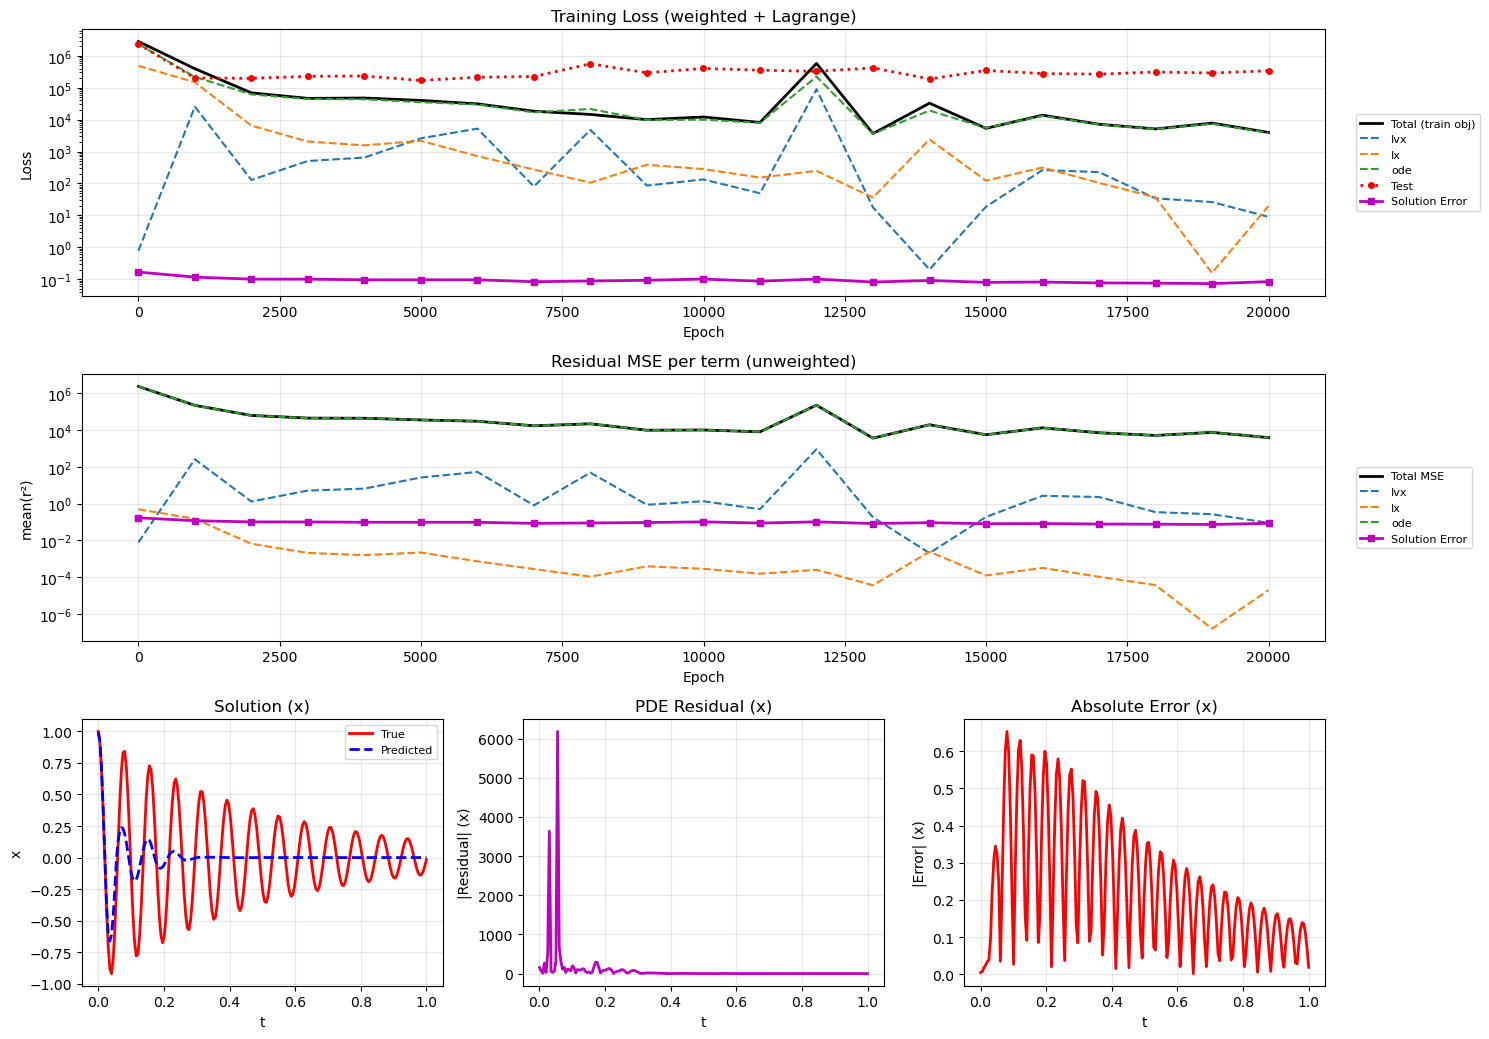

Epoch 0/20000 | Loss: 2.82e+06 | MSE: 2.33e+06 | Terms: [Ivx: 7.78e-03, Ix: 4.87e-01, ode: 2.33e+06] | Test Loss: 2.36e+06 | Error: 1.68e-01 | Time: 0.0s
Epoch 1000/20000 | Loss: 3.94e+05 | MSE: 2.18e+05 | Terms: [Ivx: 2.55e+02, Ix: 1.49e-01, ode: 2.18e+05] | Test Loss: 2.01e+05 | Error: 1.16e-01 | Time: 4.1s
Epoch 2000/20000 | Loss: 6.91e+04 | MSE: 6.17e+04 | Terms: [Ivx: 1.29e+00, Ix: 6.51e-03, ode: 6.17e+04] | Test Loss: 1.97e+05 | Error: 1.01e-01 | Time: 4.9s
Epoch 3000/20000 | Loss: 4.64e+04 | MSE: 4.43e+04 | Terms: [Ivx: 5.06e+00, Ix: 2.06e-03, ode: 4.43e+04] | Test Loss: 2.27e+05 | Error: 1.00e-01 | Time: 5.6s
Epoch 4000/20000 | Loss: 4.76e+04 | MSE: 4.35e+04 | Terms: [Ivx: 6.49e+00, Ix: 1.56e-03, ode: 4.35e+04] | Test Loss: 2.34e+05 | Error: 9.60e-02 | Time: 6.2s
Epoch 5000/20000 | Loss: 3.99e+04 | MSE: 3.51e+04 | Terms: [Ivx: 2.60e+01, Ix: 2.17e-03, ode: 3.51e+04] | Test Loss: 1.69e+05 | Error: 9.60e-02 | Time: 6.8s
Epoch 6000/20000 | Loss: 3.12e+04 | MSE: 2.99e+04 | Terms: [I

In [7]:
trainer = Trainer(network, problem=problem)

trainer.compile(
    problem={
        "ode": {"train": 1000, "test": 1000, "weight": 1.0},
        "Ix":  {"train": 1,                  "weight": 1e6},
        "Ivx": {"train": 1,                  "weight": 1e2},
    },
    optimizer=pinns.AdamOptimizer(1e-3),
    epochs=20000,
    print_each=1000,
)

trainer.train()

# Solve with FB-PINN (Finite Basis PINN)

**FB-PINN** decomposes the domain into overlapping sub-domains, each covered by a small network with a smooth window function. This improves handling of oscillatory solutions and long time evolution.

We reuse the same `problem` and `domain` — only the model changes.

## Domain partition

We tile the time axis into 10 overlapping sub-domains using `PartitionFB`. The `overlap` parameter (0 – 1) controls the width of the transition region between adjacent sub-domains.


In [8]:
domain.set_partition(time=15)   # 14 subdomains; spacing = 1/14 ≈ 0.071

network_fb = create_model(
    domain,
    output_dim=1,
    hidden_dims=(32,),
    activation="tanh",
    partition=PartitionFB(overlap=2.1),
    denormalize=False,
    output_range=None,
)
print(network_fb)


ModelPartitioned(shape=15, strategy=PartitionFB, n_models=15, output_dim=1)
  ├─ sub_0: PartitionFB(window='hann', overlap=2.1, center=[0.03333333333333333], wmin=[0.14], wmax=[0.14])
  ├─ sub_1: PartitionFB(window='hann', overlap=2.1, center=[0.1], wmin=[0.14], wmax=[0.14])
  ├─ sub_2: PartitionFB(window='hann', overlap=2.1, center=[0.16666666666666669], wmin=[0.14000000000000004], wmax=[0.14000000000000004])
  ├─ sub_3: PartitionFB(window='hann', overlap=2.1, center=[0.23333333333333334], wmin=[0.13999999999999999], wmax=[0.13999999999999999])
  ├─ sub_4: PartitionFB(window='hann', overlap=2.1, center=[0.3], wmin=[0.13999999999999999], wmax=[0.13999999999999999])
  ├─ sub_5: PartitionFB(window='hann', overlap=2.1, center=[0.3666666666666667], wmin=[0.1400000000000001], wmax=[0.1400000000000001])
  └─ … (9 more)


## Training

Same `problem` as before — the partition is embedded in `network_fb`.


Starting training for 20000 epochs (JIT-compiled)...


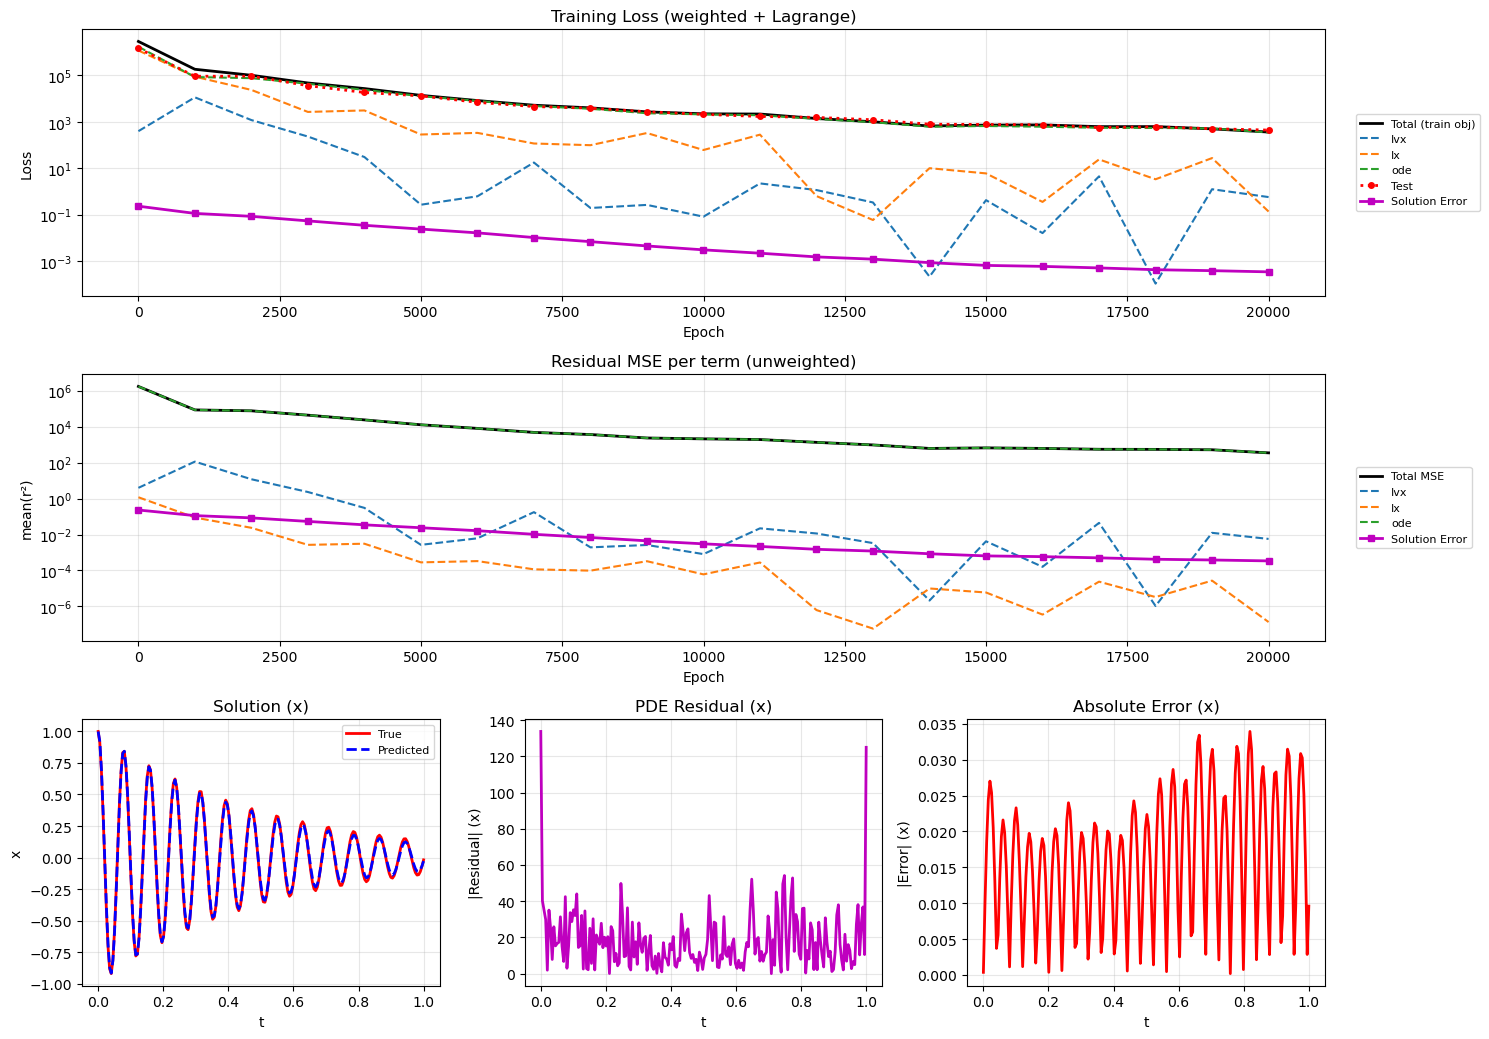

Epoch 0/20000 | Loss: 2.89e+06 | MSE: 1.71e+06 | Terms: [Ivx: 3.94e+00, Ix: 1.18e+00, ode: 1.71e+06] | Test Loss: 1.46e+06 | Error: 2.30e-01 | Time: 0.0s
Epoch 1000/20000 | Loss: 1.83e+05 | MSE: 8.47e+04 | Terms: [Ivx: 1.13e+02, Ix: 8.77e-02, ode: 8.46e+04] | Test Loss: 9.17e+04 | Error: 1.12e-01 | Time: 7.2s
Epoch 2000/20000 | Loss: 1.01e+05 | MSE: 7.57e+04 | Terms: [Ivx: 1.18e+01, Ix: 2.36e-02, ode: 7.56e+04] | Test Loss: 9.16e+04 | Error: 8.41e-02 | Time: 8.8s
Epoch 3000/20000 | Loss: 4.69e+04 | MSE: 4.33e+04 | Terms: [Ivx: 2.31e+00, Ix: 2.66e-03, ode: 4.33e+04] | Test Loss: 3.61e+04 | Error: 5.35e-02 | Time: 10.3s
Epoch 4000/20000 | Loss: 2.69e+04 | MSE: 2.37e+04 | Terms: [Ivx: 3.02e-01, Ix: 3.07e-03, ode: 2.37e+04] | Test Loss: 1.83e+04 | Error: 3.45e-02 | Time: 11.8s
Epoch 5000/20000 | Loss: 1.37e+04 | MSE: 1.26e+04 | Terms: [Ivx: 2.66e-03, Ix: 2.82e-04, ode: 1.26e+04] | Test Loss: 1.30e+04 | Error: 2.37e-02 | Time: 13.3s
Epoch 6000/20000 | Loss: 8.20e+03 | MSE: 7.96e+03 | Terms:

In [9]:
trainer_fb = Trainer(network_fb, problem=problem)

trainer_fb.compile(
    problem={
        "ode": {"train": 200,  "test": 500,  "weight": 1.0},   # original: ns=((200,),), n_test=(500,)
        "Ix":  {"train": 1,                  "weight": 1e6},   # original: 1e6
        "Ivx": {"train": 1,                  "weight": 1e2},   # original: 1e2
    },
    optimizer=pinns.AdamOptimizer(1e-3),
    epochs=20000,         # matches original n_steps=20000
    print_each=1000,
    schedulers=[
        pinns.SchedulerResample(1),   # resample every epoch — matches paper
    ],
)

trainer_fb.train()